In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('D:\AMNIL-Internship\Mall_Customers.csv')

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Anuraj Sapkota\AppData\Local\Temp\ipykernel_3904\1019379521.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv('D:\AMNIL-Internship\Mall_Customers.csv')


In [32]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [34]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [35]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [36]:
df.drop('CustomerID', axis=1, inplace = True)

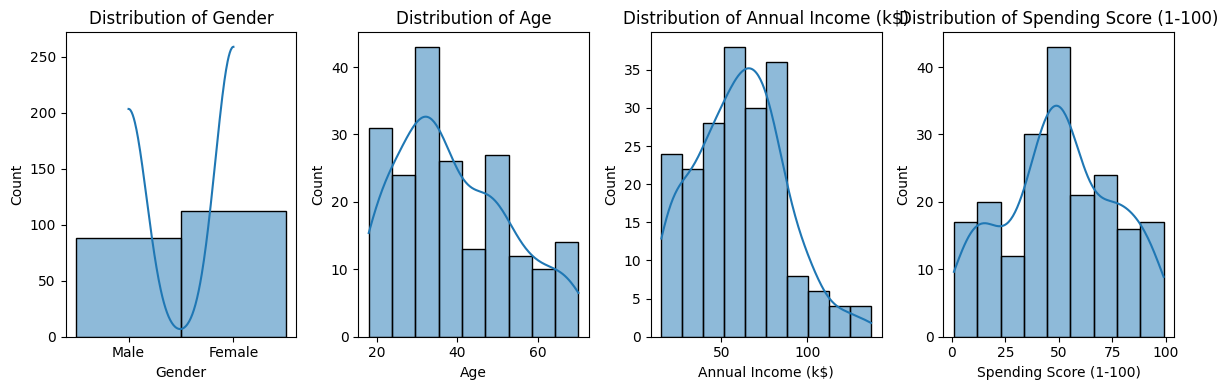

In [37]:
# Visualizations
# histogram for distributions
plt.figure(figsize=(12,4))
for i, col in enumerate(df):
    plt.subplot(1,4,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

C:\Users\Anuraj Sapkota\AppData\Local\Temp\ipykernel_3904\782105535.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='deep')


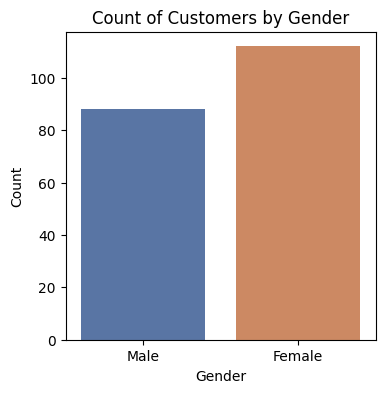

In [38]:
plt.figure(figsize=(4, 4))
sns.countplot(x='Gender', data=df, palette='deep')
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plot age vs spending score

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

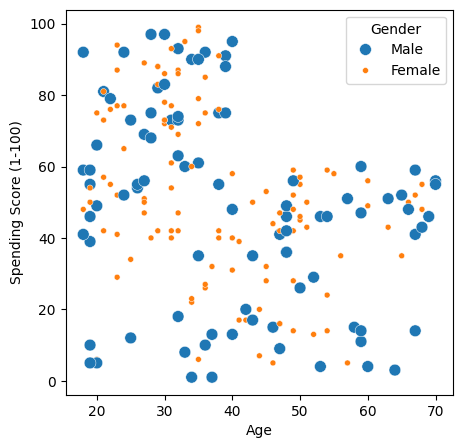

In [39]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df, hue='Gender', size='Gender')

plot annual income bs spending score

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

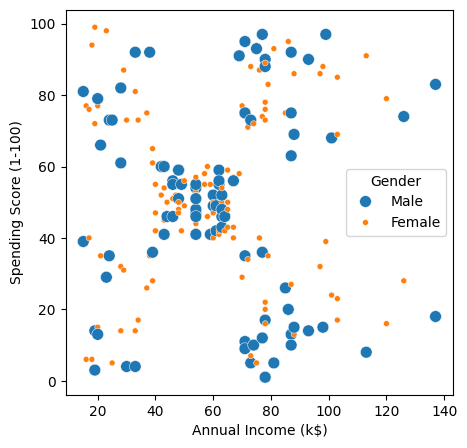

In [40]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', size='Gender')

plot age vs annual income

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

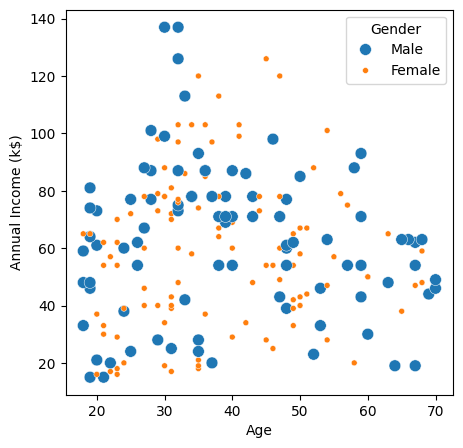

In [41]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df, hue='Gender', size='Gender')

## Data preprocessing
* Dropping unnecessary feature done
* Two type of features:
  * categorical feature: 'Gender'. OneHotEncoder encodes Gender.
  * numerical feature: Age, Annual Income, Spending Score.
    * Since, numerical datapoints varies from small numbers to large number. so, most of them might not contribute to form cluster as algotrithm uses distance to form groupings.
    * StandardScaler standardized datapoints and make them contribute equally to form cluster.

In [42]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

In [43]:
km_features = df[['Annual Income (k$)','Spending Score (1-100)']].copy()
km_features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [44]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_km_features = scaler.fit_transform(km_features)
X_scaled


array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [45]:
X_scaled_km_features

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

# KMeans Clustring
* Spherical clusters about centroids
* No of clusters is find out using Elbow method and Silhoutte score
* Cluster with highest silhoutte score is considered
* Kmeans1 is for Dataset having all feautres
* Kmeans2 use only 2 features: Annual Income and Spending Score

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [47]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


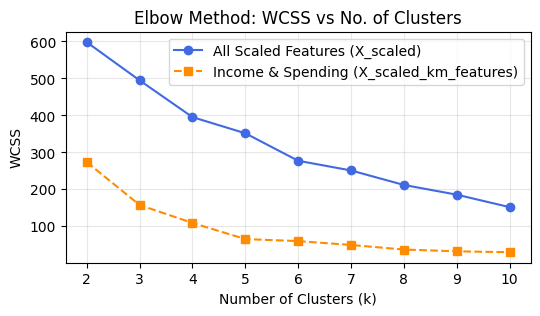

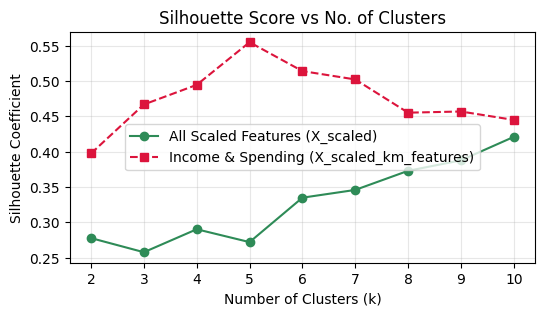

In [48]:
## Manual Process
## ELbow Method to select the K value

wcss = []
wcss2 = []
silhouette_coefficients1 = []
silhouette_coefficients2 = []
for k in range(2,11):
    kmeans1=KMeans(n_clusters=k,random_state=42)
    kmeans1.fit(X_scaled)
    wcss.append(kmeans1.inertia_)
    score1 = silhouette_score(X_scaled,kmeans1.labels_)
    silhouette_coefficients1.append(score1)

    kmeans2=KMeans(n_clusters=k,random_state=42)
    kmeans2.fit(X_scaled_km_features)
    wcss2.append(kmeans2.inertia_)
    score2 = silhouette_score(X_scaled_km_features,kmeans2.labels_)
    silhouette_coefficients2.append(score2)


## Elbow Curves
plt.figure(figsize=(6, 3))
plt.plot(range(2, 11), wcss, marker='o', color='royalblue', linestyle='-', label='All Scaled Features (X_scaled)')
plt.plot(range(2, 11), wcss2, marker='s', color='darkorange', linestyle='--', label='Income & Spending (X_scaled_km_features)')
plt.title("Elbow Method: WCSS vs No. of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Silhouette Scores
plt.figure(figsize=(6, 3))
plt.plot(range(2, 11), silhouette_coefficients1, marker='o', color='seagreen', linestyle='-', label='All Scaled Features (X_scaled)')
plt.plot(range(2, 11), silhouette_coefficients2, marker='s', color='crimson', linestyle='--', label='Income & Spending (X_scaled_km_features)')
plt.title("Silhouette Score vs No. of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Coefficient")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [49]:
# Knee locator
from kneed import  KneeLocator
kl=KneeLocator(range(2,11),wcss,curve='convex',direction='decreasing')
print(kl.elbow)
kl2=KneeLocator(range(2,11),wcss2,curve='convex',direction='decreasing')
print(kl2.elbow)

6
5


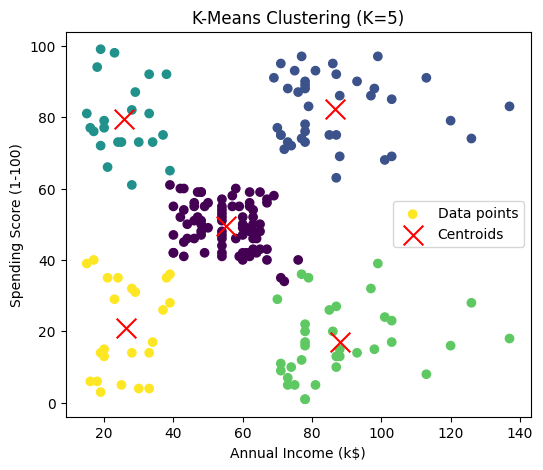

In [50]:
# Fit K-means
km = KMeans(n_clusters=5, n_init=10, random_state=42)
km_features['Cluster'] = km.fit_predict(X_scaled_km_features)  
km_labels = km.labels_

centers_original = scaler.inverse_transform(km.cluster_centers_)  
plt.figure(figsize=(6, 5))
plt.scatter(km_features['Annual Income (k$)'], km_features['Spending Score (1-100)'], c=km_features['Cluster'], cmap='viridis', label='Data points')
plt.scatter(centers_original[:, 0], centers_original[:, 1], s=200, c='red', marker='x', label='Centroids')  # Income, Spending
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means Clustering (K={5})')
plt.legend()
plt.show()

# DBSCAN
* Non Linear Clustring
* Two hyper parameters:
    * minimum_pts: no of points that should be included in a circle of radius epsilon to be a cluster.
    * epsilon or eps: radius
* Three type of points:
    * Core points:  datapoints that are greater than min_points inside radius.
 * Border Points: Datapoints within the radius will be less than min_pts
 * Noise or outliers: No any datapoints inside radius.
* It is robust to outliers

In [72]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from random import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

* min_sample is twice the no of featutes.
* eps is calculated using K-distance plot

C:\Users\Anuraj Sapkota\AppData\Local\Temp\ipykernel_3904\2998270392.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


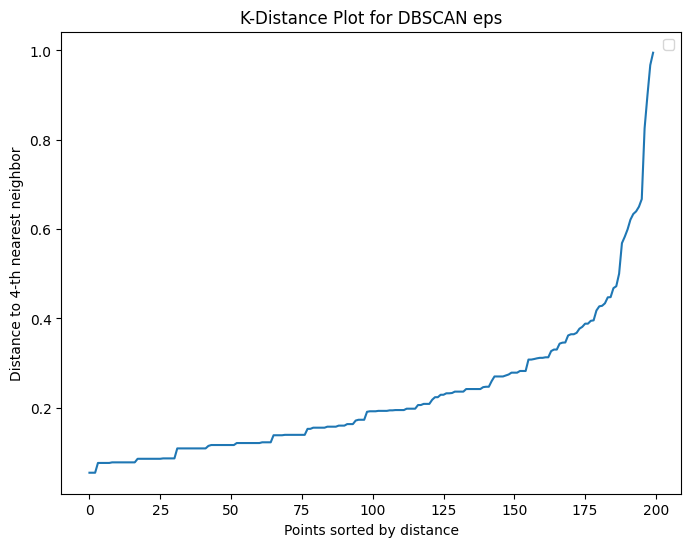

In [82]:
min_samples = 4  
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled_km_features)
distances, indices = neighbors_fit.kneighbors(X_scaled_km_features)

# Sort distances to the min_samples-th neighbor
distances = np.sort(distances[:, min_samples-1])

# Plot k-distance graph
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}-th nearest neighbor')
plt.title('K-Distance Plot for DBSCAN eps')
plt.legend()
plt.show()

In [75]:
dbscan = DBSCAN(eps=0.4, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled_km_features)

X_dbscan = pd.DataFrame(X_scaled_km_features, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
X_dbscan['Cluster'] = dbscan_labels

X_dbscan.head()

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters found (excluding noise): {n_clusters}")

Number of clusters found (excluding noise): 3


## Use randomizedSearchCV for best eps and min_samples

In [76]:
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:  # Silhouette score requires at least 2 clusters
        return silhouette_score(X, labels)
    return -1

In [94]:
dbscan2 = DBSCAN()

param_dist = {
    'eps': np.arange(0.1,1.1,0.1),
    'min_samples': np.arange(3,10,1)
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=dbscan2,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter combinations to try
    scoring=silhouette_scorer,
    random_state=42,
  
)

# Fit RandomizedSearchCV
random_search.fit(X_scaled_km_features)

results = pd.DataFrame(random_search.cv_results_)
results = results[['param_eps', 'param_min_samples', 'mean_test_score']]
results.columns = ['eps', 'min_samples', 'silhouette_score']
results = results.sort_values(by='silhouette_score', ascending=False)

print("Top 5 parameter combinations:")
print(results.head())
print(f"Best eps: {random_search.best_params_['eps']:.3f}")
print(f"Best min_samples: {random_search.best_params_['min_samples']}")
print(f"Best silhouette score: {random_search.best_score_:.3f}")

Top 5 parameter combinations:
    eps  min_samples  silhouette_score
17  0.6            3          0.019029
19  0.7            8          0.001713
15  0.5            5         -0.054318
0   0.4            4         -0.102149
10  0.5            6         -0.117014
Best eps: 0.600
Best min_samples: 3
Best silhouette score: 0.019


### Plotted on eps 0.4 and min_samples 4
* randomized cv doesnt give as expected result

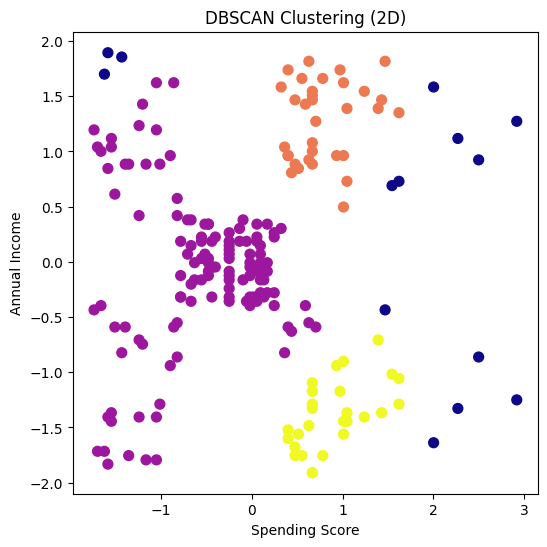

In [64]:
plt.figure(figsize=(6,6))
plt.scatter(
    X_scaled_km_features[:, 0], 
    X_scaled_km_features[:, 1],
    c=dbscan_labels, 
    cmap='plasma', 
    s=50
)

plt.title("DBSCAN Clustering (2D)")
plt.ylabel("Annual Income")
plt.xlabel("Spending Score")
plt.show()

In [85]:
from sklearn.metrics import silhouette_score, silhouette_samples

In [86]:
if n_clusters > 1:  # Silhouette score requires at least 2 clusters
    silhouette_avg = silhouette_score(X_scaled_km_features, dbscan_labels)
    sample_silhouette_values = silhouette_samples(X_scaled_km_features, dbscan_labels)
    print(f"Average silhouette score: {silhouette_avg:.3f}")
else:
    print("Not enough clusters to compute silhouette score.")
    sample_silhouette_values = np.zeros_like(dbscan_labels, dtype=float)

Average silhouette score: 0.398
